# Modelo juego — entrenamiento con 1 millón de Sudokus

Esta es una versión documentada para entrenar y comparar dos modelos:

1. **CNN** con información del tablero y candidatos legales.
2. **Bidirectional LSTM** con el tablero como secuencia de 81 posiciones.

Los modelos se entrenan con estados parciales para parecerse al funcionamiento real del backtracking.

Al final se comparan:

- accuracy en celdas vacías;
- Sudokus exactos y válidos en predicción directa;
- Sudokus exactos y válidos con backtracking;
- tiempo, nodos y retrocesos.

Después de revisar los resultados se preparará una versión final más compacta.

## PASO 1 · Conectar Google Drive

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## PASO 2 · Importar librerías

In [2]:
import os
import gc
import time
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

print("TensorFlow:", tf.__version__)
print("GPU disponible:", len(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.20.0
GPU disponible: 1


## PASO 3 · Configuración

El CSV completo contiene aproximadamente nueve millones de Sudokus.

En esta prueba utilizaremos un millón.

In [3]:
ruta_modelo_juego = (
    "/content/drive/MyDrive/"
    "proyecto_DL/modelo_juego"
)

ruta_csv = os.path.join(
    ruta_modelo_juego,
    "data",
    "sudoku.csv"
)

ruta_modelos = os.path.join(
    ruta_modelo_juego,
    "modelo"
)

ruta_cnn = os.path.join(
    ruta_modelos,
    "best_cnn_1M.keras"
)

ruta_lstm = os.path.join(
    ruta_modelos,
    "best_lstm_1M.keras"
)

ruta_mejor_modelo = os.path.join(
    ruta_modelos,
    "best_juego.keras"
)

ruta_tipo_modelo = os.path.join(
    ruta_modelos,
    "tipo_modelo.txt"
)

NUM_SUDOKUS = 1000000
EPOCHS = 15
BATCH_SIZE = 512

NUM_TEST_DIRECTO = 10000
NUM_TEST_BACKTRACKING = 100
MAX_NODOS = 100000

os.makedirs(
    ruta_modelos,
    exist_ok=True
)

print("Sudokus:", NUM_SUDOKUS)
print("Dataset:", ruta_csv)

Sudokus: 1000000
Dataset: /content/drive/MyDrive/proyecto_DL/modelo_juego/data/sudoku.csv


## PASO 4 · Cargar los datos

In [4]:
df = pd.read_csv(
    ruta_csv,
    nrows=NUM_SUDOKUS,
    dtype=str
)

print("Dimensión:", df.shape)
print("Nulos:", df.isnull().sum().sum())
print("Duplicados:", df.duplicated().sum())

df.head()

Dimensión: (1000000, 2)
Nulos: 0
Duplicados: 0


,puzzle,solution
0,0700000430400096108006349000940520003584600200...,6795182435437296188216349577943521863584617292...
1,3010865040465210705000000014008000020803479000...,3719865248465213795924738614638197522853479167...
2,0483015603600080909106700030200009355090102006...,7483915623652487919126754834217869355894132766...
3,0083170000042051090000400703271609049014500000...,2983176457642851391539462783271689549814537266...
4,0408906300001368208007405190004670524500207002...,1428956379751368248367425193984671524513287962...


In [5]:
X = np.array(
    [
        list(sudoku)
        for sudoku in df["puzzle"]
    ],
    dtype=np.int8
).reshape(-1, 9, 9)

y = np.array(
    [
        list(sudoku)
        for sudoku in df["solution"]
    ],
    dtype=np.int8
).reshape(-1, 9, 9)

print("X:", X.shape)
print("y:", y.shape)
print("Valores de X:", np.unique(X))
print("Valores de y:", np.unique(y))

del df
gc.collect()

X: (1000000, 9, 9)
y: (1000000, 9, 9)
Valores de X: [0 1 2 3 4 5 6 7 8 9]
Valores de y: [1 2 3 4 5 6 7 8 9]


0

## PASO 5 · Separar train, validación y test

Los dos modelos utilizarán exactamente los mismos datos:

- 80 % entrenamiento;
- 10 % validación;
- 10 % test.

In [6]:
X_train, X_temporal, y_train, y_temporal = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temporal,
    y_temporal,
    test_size=0.5,
    random_state=42
)

print("Train:", X_train.shape)
print("Validación:", X_val.shape)
print("Test:", X_test.shape)

del X
del y
del X_temporal
del y_temporal
gc.collect()

Train: (800000, 9, 9)
Validación: (100000, 9, 9)
Test: (100000, 9, 9)


0

## PASO 6 · Crear estados parciales

Durante la resolución con backtracking el modelo recibe:

```text
puzzle inicial
→ puzzle parcialmente completado
→ puzzle casi resuelto
```

Para simularlo durante el entrenamiento, revelaremos aleatoriamente parte de las celdas vacías usando la solución correcta.

No se genera un CSV nuevo. Los estados parciales se crean dentro de cada batch.

In [7]:
def crear_estado_parcial(puzzles, soluciones):

    estados = puzzles.copy()

    probabilidad_revelar = np.random.uniform(
        0.0,
        0.8,
        size=(len(puzzles), 1, 1)
    )

    revelar = (
        (puzzles == 0)
        & (
            np.random.random(puzzles.shape)
            < probabilidad_revelar
        )
    )

    estados[revelar] = soluciones[revelar]

    return estados

In [8]:
estado_ejemplo = crear_estado_parcial(
    X_train[:1],
    y_train[:1]
)[0]

print("PUZZLE ORIGINAL")
print(X_train[0])

print("\nESTADO PARCIAL")
print(estado_ejemplo)

print("\nSOLUCIÓN")
print(y_train[0])

PUZZLE ORIGINAL
[[8 0 0 0 0 7 0 2 3]
 [0 0 0 1 4 2 8 0 5]
 [9 0 0 8 3 0 0 6 4]
 [3 9 0 0 0 0 0 0 7]
 [5 0 8 7 1 9 0 0 0]
 [0 7 4 3 0 0 0 1 0]
 [0 5 0 4 9 8 2 7 6]
 [0 0 6 0 0 0 0 0 1]
 [0 0 9 0 5 1 4 3 8]]

ESTADO PARCIAL
[[8 0 0 0 0 7 0 2 3]
 [0 0 0 1 4 2 8 9 5]
 [9 0 0 8 3 0 0 6 4]
 [3 9 0 0 0 4 0 0 7]
 [5 0 8 7 1 9 0 4 0]
 [0 7 4 3 0 0 0 1 9]
 [0 5 0 4 9 8 2 7 6]
 [0 0 6 0 0 0 0 0 1]
 [0 0 9 0 5 1 4 3 8]]

SOLUCIÓN
[[8 4 5 9 6 7 1 2 3]
 [6 3 7 1 4 2 8 9 5]
 [9 1 2 8 3 5 7 6 4]
 [3 9 1 5 2 4 6 8 7]
 [5 6 8 7 1 9 3 4 2]
 [2 7 4 3 8 6 5 1 9]
 [1 5 3 4 9 8 2 7 6]
 [4 8 6 2 7 3 9 5 1]
 [7 2 9 6 5 1 4 3 8]]


## PASO 7 · Crear los candidatos legales

Para cada celda se crean nueve canales:

```text
canal 1 → el número 1 puede colocarse
canal 2 → el número 2 puede colocarse
...
canal 9 → el número 9 puede colocarse
```

La CNN recibirá:

```text
10 canales del tablero
+
9 canales de candidatos
=
19 canales
```

In [9]:
def crear_candidatos(tableros):

    tablero_one_hot = keras.utils.to_categorical(
        tableros,
        num_classes=10
    ).astype("float32")

    numeros = tablero_one_hot[..., 1:]

    usados_fila = numeros.max(
        axis=2
    )[:, :, None, :]

    usados_columna = numeros.max(
        axis=1
    )[:, None, :, :]

    bloques = numeros.reshape(
        -1,
        3,
        3,
        3,
        3,
        9
    )

    usados_bloque = bloques.max(
        axis=(2, 4)
    )

    usados_bloque = np.repeat(
        np.repeat(
            usados_bloque,
            3,
            axis=1
        ),
        3,
        axis=2
    )

    candidatos = (
        1
        - np.maximum.reduce(
            [
                np.broadcast_to(
                    usados_fila,
                    numeros.shape
                ),
                np.broadcast_to(
                    usados_columna,
                    numeros.shape
                ),
                usados_bloque
            ]
        )
    )

    candidatos[tableros != 0] = 0

    return candidatos.astype("float32")

In [10]:
def crear_entrada_cnn(tableros):

    tablero_one_hot = keras.utils.to_categorical(
        tableros,
        num_classes=10
    ).astype("float32")

    candidatos = crear_candidatos(
        tableros
    )

    return np.concatenate(
        [
            tablero_one_hot,
            candidatos
        ],
        axis=-1
    )

In [11]:
entrada_ejemplo = crear_entrada_cnn(
    estado_ejemplo.reshape(1, 9, 9)
)

print("Entrada CNN:", entrada_ejemplo.shape)
print("Canales del tablero:", entrada_ejemplo.shape[-1] - 9)
print("Canales de candidatos:", 9)

Entrada CNN: (1, 9, 9, 19)
Canales del tablero: 10
Canales de candidatos: 9


## PASO 8 · Generador de batches

Crear todas las entradas de 19 canales para un millón de Sudokus ocuparía demasiada memoria.

El generador:

1. selecciona un batch;
2. crea estados parciales;
3. prepara la entrada del modelo;
4. aplica pérdida únicamente a las celdas todavía vacías.

In [12]:
class SudokuSequence(keras.utils.Sequence):

    def __init__(
        self,
        puzzles,
        soluciones,
        batch_size,
        tipo_modelo,
        shuffle=True,
        estados_parciales=True
    ):

        super().__init__()

        self.puzzles = puzzles
        self.soluciones = soluciones
        self.batch_size = batch_size
        self.tipo_modelo = tipo_modelo
        self.shuffle = shuffle
        self.estados_parciales = estados_parciales
        self.indices = np.arange(len(puzzles))

        self.on_epoch_end()

    def __len__(self):

        return int(
            np.ceil(
                len(self.puzzles)
                / self.batch_size
            )
        )

    def __getitem__(self, posicion):

        indices = self.indices[
            posicion * self.batch_size:
            (posicion + 1) * self.batch_size
        ]

        puzzles = self.puzzles[indices]
        soluciones = self.soluciones[indices]

        if self.estados_parciales:

            estados = crear_estado_parcial(
                puzzles,
                soluciones
            )

        else:

            estados = puzzles.copy()

        pesos = (
            estados == 0
        ).astype("float32")

        target = (
            soluciones - 1
        ).astype("int8")

        if self.tipo_modelo == "cnn":

            entrada = crear_entrada_cnn(
                estados
            )

            return entrada, target, pesos

        entrada = estados.reshape(
            -1,
            81
        ).astype("int8")

        target = target.reshape(
            -1,
            81
        )

        pesos = pesos.reshape(
            -1,
            81
        )

        return entrada, target, pesos

    def on_epoch_end(self):

        if self.shuffle:

            np.random.shuffle(
                self.indices
            )

In [13]:
train_cnn = SudokuSequence(
    X_train,
    y_train,
    BATCH_SIZE,
    tipo_modelo="cnn"
)

val_cnn = SudokuSequence(
    X_val,
    y_val,
    BATCH_SIZE,
    tipo_modelo="cnn",
    shuffle=False
)

train_lstm = SudokuSequence(
    X_train,
    y_train,
    BATCH_SIZE,
    tipo_modelo="lstm"
)

val_lstm = SudokuSequence(
    X_val,
    y_val,
    BATCH_SIZE,
    tipo_modelo="lstm",
    shuffle=False
)

entrada_cnn, target_cnn, pesos_cnn = train_cnn[0]
entrada_lstm, target_lstm, pesos_lstm = train_lstm[0]

print("CNN:", entrada_cnn.shape, target_cnn.shape, pesos_cnn.shape)
print("LSTM:", entrada_lstm.shape, target_lstm.shape, pesos_lstm.shape)

CNN: (512, 9, 9, 19) (512, 9, 9) (512, 9, 9)
LSTM: (512, 81) (512, 81) (512, 81)


# MODELO 1 · CNN

La estructura se escribe de forma compacta, siguiendo el patrón utilizado en clase.

## PASO 9 · Crear y compilar la CNN

In [14]:
modelo_cnn = keras.Sequential([
    keras.Input(shape=(9, 9, 19)),
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.Dropout(0.2),
    layers.Conv2D(256, 3, padding="same", activation="relu"),
    layers.Conv2D(256, 3, padding="same", activation="relu"),
    layers.Dropout(0.2),
    layers.Conv2D(9, 1, padding="same", activation="softmax")
])

modelo_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    weighted_metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

modelo_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 9, 9, 128)      │        22,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 9, 9, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 9, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 9, 9, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 9, 9, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 9, 9, 9)        │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,204,745 (4.60 MB)

 Trainable params: 1,204,745 (4.60 MB)

 Non-trainable params: 0 (0.00 B)

## PASO 10 · Entrenar la CNN

In [15]:
checkpoint_cnn = keras.callbacks.ModelCheckpoint(
    ruta_cnn,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_cnn = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_cnn = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

history_cnn = modelo_cnn.fit(
    train_cnn,
    validation_data=val_cnn,
    epochs=EPOCHS,
    callbacks=[
        checkpoint_cnn,
        early_cnn,
        reduce_cnn
    ],
    verbose=1
)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7819 - loss: 0.1744
Epoch 1: val_accuracy improved from None to 0.89115, saving model to /content/drive/MyDrive/proyecto_DL/modelo_juego/modelo/best_cnn_1M.keras

Epoch 1: finished saving model to /content/drive/MyDrive/proyecto_DL/modelo_juego/modelo/best_cnn_1M.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 144s 84ms/step - accuracy: 0.8470 - loss: 0.1117 - val_accuracy: 0.8911 - val_loss: 0.0736 - learning_rate: 0.0010
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8887 - loss: 0.0762
Epoch 2: val_accuracy improved from 0.89115 to 0.90721, saving model to /content/drive/MyDrive/proyecto_DL/modelo_juego/modelo/best_cnn_1M.keras

Epoch 2: finished saving model to /content/drive/MyDrive/proyecto_DL/modelo_juego/modelo/best_cnn_1M.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 133s 85ms/step - accuracy: 0.8933 - loss: 0.0731 - val_accuracy: 0.9072 - val_loss: 0.0625 - learning_rate: 0.0010
Epoch 3/15
1563/1563 ━━━━━━

## PASO 11 · Curvas de la CNN

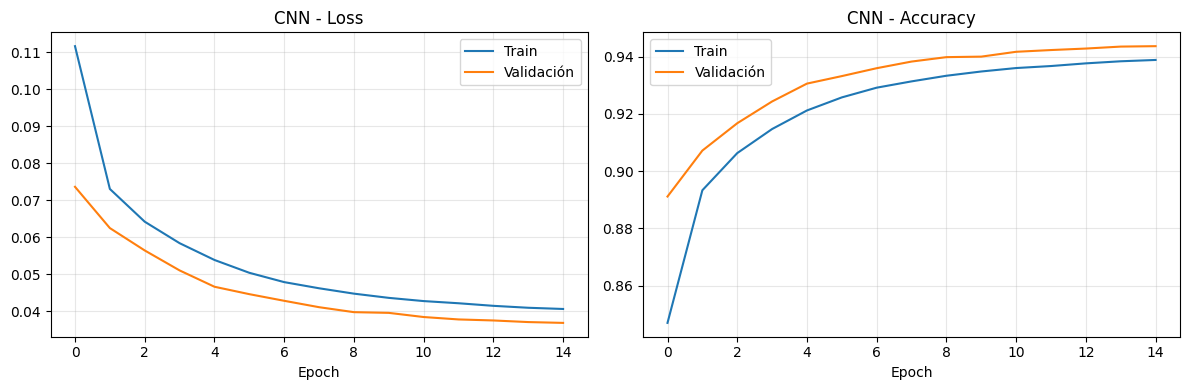

In [16]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(
    history_cnn.history["loss"],
    label="Train"
)
plt.plot(
    history_cnn.history["val_loss"],
    label="Validación"
)
plt.title("CNN - Loss")
plt.xlabel("Epoch")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(
    history_cnn.history["accuracy"],
    label="Train"
)
plt.plot(
    history_cnn.history["val_accuracy"],
    label="Validación"
)
plt.title("CNN - Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# MODELO 2 · BIDIRECTIONAL LSTM

La LSTM recibe el tablero como una secuencia de 81 valores.

La arquitectura mantiene el patrón compacto visto en clase.

## PASO 12 · Crear y compilar la LSTM

In [17]:
modelo_lstm = keras.Sequential([
    keras.Input(shape=(81,)),
    layers.Embedding(input_dim=10, output_dim=64),
    layers.Bidirectional(
        layers.LSTM(128, return_sequences=True)
    ),
    layers.Dropout(0.2),
    layers.Bidirectional(
        layers.LSTM(128, return_sequences=True)
    ),
    layers.Dropout(0.2),
    layers.Dense(9, activation="softmax")
])

modelo_lstm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    weighted_metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

modelo_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 81, 64)         │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 81, 256)        │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 81, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 81, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 81, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 81, 9)          │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 594,825 (2.27 MB)

 Trainable params: 594,825 (2.27 MB)

 Non-trainable params: 0 (0.00 B)

## PASO 13 · Entrenar la LSTM

In [18]:
checkpoint_lstm = keras.callbacks.ModelCheckpoint(
    ruta_lstm,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_lstm = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lstm = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

history_lstm = modelo_lstm.fit(
    train_lstm,
    validation_data=val_lstm,
    epochs=EPOCHS,
    callbacks=[
        checkpoint_lstm,
        early_lstm,
        reduce_lstm
    ],
    verbose=1
)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.3130 - loss: 0.5028
Epoch 1: val_accuracy improved from None to 0.56441, saving model to /content/drive/MyDrive/proyecto_DL/modelo_juego/modelo/best_lstm_1M.keras

Epoch 1: finished saving model to /content/drive/MyDrive/proyecto_DL/modelo_juego/modelo/best_lstm_1M.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 159s 98ms/step - accuracy: 0.3843 - loss: 0.4299 - val_accuracy: 0.5644 - val_loss: 0.2941 - learning_rate: 0.0010
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.5788 - loss: 0.2788
Epoch 2: val_accuracy improved from 0.56441 to 0.63141, saving model to /content/drive/MyDrive/proyecto_DL/modelo_juego/modelo/best_lstm_1M.keras

Epoch 2: finished saving model to /content/drive/MyDrive/proyecto_DL/modelo_juego/modelo/best_lstm_1M.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 152s 97ms/step - accuracy: 0.5993 - loss: 0.2584 - val_accuracy: 0.6314 - val_loss: 0.2208 - learning_rate: 0.0010
Epoch 3/15
1563/1563 ━━

## PASO 14 · Curvas de la LSTM

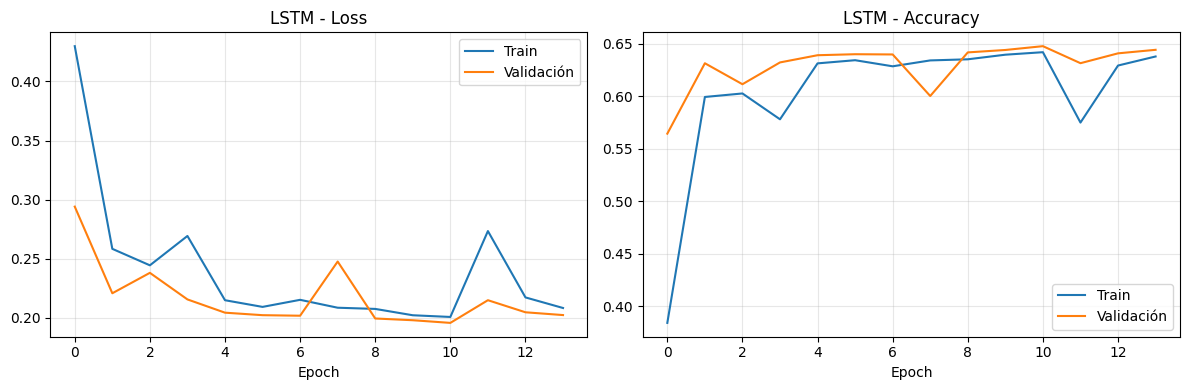

In [19]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(
    history_lstm.history["loss"],
    label="Train"
)
plt.plot(
    history_lstm.history["val_loss"],
    label="Validación"
)
plt.title("LSTM - Loss")
plt.xlabel("Epoch")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(
    history_lstm.history["accuracy"],
    label="Train"
)
plt.plot(
    history_lstm.history["val_accuracy"],
    label="Validación"
)
plt.title("LSTM - Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluación directa

La predicción directa completa todas las celdas vacías en un único paso.

Se evaluará sobre una muestra del conjunto de test para evitar consumir demasiada memoria.

In [20]:
def sudoku_valido(tablero):

    numeros = set(range(1, 10))

    for i in range(9):

        if set(tablero[i, :]) != numeros:
            return False

        if set(tablero[:, i]) != numeros:
            return False

    for fila in range(0, 9, 3):
        for columna in range(0, 9, 3):

            bloque = tablero[
                fila:fila + 3,
                columna:columna + 3
            ]

            if set(bloque.flatten()) != numeros:
                return False

    return True

In [21]:
def predecir_directo(
    modelo,
    puzzles,
    tipo_modelo
):

    if tipo_modelo == "cnn":

        entrada = crear_entrada_cnn(
            puzzles
        )

        probabilidades = modelo.predict(
            entrada,
            batch_size=512,
            verbose=1
        )

    else:

        entrada = puzzles.reshape(
            -1,
            81
        )

        probabilidades = modelo.predict(
            entrada,
            batch_size=512,
            verbose=1
        )

        probabilidades = probabilidades.reshape(
            -1,
            9,
            9,
            9
        )

    predicciones = (
        np.argmax(
            probabilidades,
            axis=-1
        )
        + 1
    )

    resultados = np.where(
        puzzles != 0,
        puzzles,
        predicciones
    )

    return resultados

In [22]:
def calcular_metricas_directas(
    puzzles,
    soluciones,
    resultados
):

    mascara_vacias = puzzles == 0

    accuracy_vacias = np.mean(
        resultados[mascara_vacias]
        == soluciones[mascara_vacias]
    )

    exactos = np.mean(
        np.all(
            resultados == soluciones,
            axis=(1, 2)
        )
    )

    validos = np.mean(
        [
            sudoku_valido(tablero)
            for tablero in resultados
        ]
    )

    return {
        "accuracy_vacias": accuracy_vacias,
        "sudokus_exactos": exactos,
        "sudokus_validos": validos
    }

In [23]:
modelo_cnn = keras.models.load_model(
    ruta_cnn
)

modelo_lstm = keras.models.load_model(
    ruta_lstm
)

puzzles_directo = X_test[
    :NUM_TEST_DIRECTO
]

soluciones_directo = y_test[
    :NUM_TEST_DIRECTO
]

resultados_cnn = predecir_directo(
    modelo_cnn,
    puzzles_directo,
    "cnn"
)

resultados_lstm = predecir_directo(
    modelo_lstm,
    puzzles_directo,
    "lstm"
)

metricas_cnn = calcular_metricas_directas(
    puzzles_directo,
    soluciones_directo,
    resultados_cnn
)

metricas_lstm = calcular_metricas_directas(
    puzzles_directo,
    soluciones_directo,
    resultados_lstm
)

print("CNN:", metricas_cnn)
print("LSTM:", metricas_lstm)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
CNN: {'accuracy_vacias': np.float64(0.8047961391483611), 'sudokus_exactos': np.float64(0.1033), 'sudokus_validos': np.float64(0.1033)}
LSTM: {'accuracy_vacias': np.float64(0.4729377005417447), 'sudokus_exactos': np.float64(0.0003), 'sudokus_validos': np.float64(0.0003)}


# Evaluación con backtracking

El backtracking no forma parte del entrenamiento.

La red ordena los candidatos, MRV selecciona la celda más restringida y el backtracking deshace decisiones incorrectas.

In [24]:
def candidatos_validos(
    tablero,
    fila,
    columna
):

    usados = set(tablero[fila, :])
    usados.update(tablero[:, columna])

    fila_bloque = (fila // 3) * 3
    columna_bloque = (columna // 3) * 3

    usados.update(
        tablero[
            fila_bloque:fila_bloque + 3,
            columna_bloque:columna_bloque + 3
        ].flatten()
    )

    return [
        numero
        for numero in range(1, 10)
        if numero not in usados
    ]

In [25]:
def seleccionar_celda_mrv(tablero):

    mejor_celda = None
    mejores_candidatos = None

    for fila in range(9):
        for columna in range(9):

            if tablero[fila, columna] != 0:
                continue

            candidatos = candidatos_validos(
                tablero,
                fila,
                columna
            )

            if len(candidatos) == 0:
                return fila, columna, []

            if (
                mejores_candidatos is None
                or len(candidatos)
                < len(mejores_candidatos)
            ):

                mejor_celda = (
                    fila,
                    columna
                )

                mejores_candidatos = candidatos

            if len(mejores_candidatos) == 1:
                break

        if (
            mejores_candidatos is not None
            and len(mejores_candidatos) == 1
        ):
            break

    if mejor_celda is None:
        return None

    fila, columna = mejor_celda

    return fila, columna, mejores_candidatos

In [26]:
def predecir_probabilidades(
    tablero,
    modelo,
    tipo_modelo
):

    if tipo_modelo == "cnn":

        entrada = crear_entrada_cnn(
            tablero.reshape(1, 9, 9)
        )

        probabilidades = modelo(
            entrada,
            training=False
        ).numpy()[0]

        return probabilidades

    entrada = tablero.reshape(
        1,
        81
    )

    probabilidades = modelo(
        entrada,
        training=False
    ).numpy()[0]

    return probabilidades.reshape(
        9,
        9,
        9
    )

In [27]:
def resolver_backtracking(
    puzzle,
    modelo,
    tipo_modelo,
    max_nodos=100000
):

    tablero = puzzle.copy()

    estadisticas = {
        "nodos": 0,
        "retrocesos": 0
    }

    def buscar():

        if estadisticas["nodos"] >= max_nodos:
            return False

        estadisticas["nodos"] += 1

        if 0 not in tablero:
            return sudoku_valido(tablero)

        seleccion = seleccionar_celda_mrv(
            tablero
        )

        if seleccion is None:
            return False

        fila, columna, candidatos = seleccion

        if len(candidatos) == 0:

            estadisticas["retrocesos"] += 1
            return False

        probabilidades = predecir_probabilidades(
            tablero,
            modelo,
            tipo_modelo
        )

        candidatos = sorted(
            candidatos,
            key=lambda numero: probabilidades[
                fila,
                columna,
                numero - 1
            ],
            reverse=True
        )

        for numero in candidatos:

            tablero[
                fila,
                columna
            ] = numero

            if buscar():
                return True

            tablero[
                fila,
                columna
            ] = 0

            estadisticas["retrocesos"] += 1

        return False

    resuelto = buscar()

    if resuelto:
        return tablero.copy(), estadisticas

    return None, estadisticas

In [28]:
def evaluar_backtracking(
    modelo,
    tipo_modelo,
    puzzles,
    soluciones
):

    exactos = []
    validos = []
    tiempos = []
    nodos = []
    retrocesos = []

    for i in range(len(puzzles)):

        inicio = time.time()

        tablero, estadisticas = resolver_backtracking(
            puzzles[i],
            modelo,
            tipo_modelo,
            max_nodos=MAX_NODOS
        )

        tiempos.append(
            time.time() - inicio
        )

        nodos.append(
            estadisticas["nodos"]
        )

        retrocesos.append(
            estadisticas["retrocesos"]
        )

        if tablero is None:

            exactos.append(False)
            validos.append(False)

        else:

            exactos.append(
                np.array_equal(
                    tablero,
                    soluciones[i]
                )
            )

            validos.append(
                sudoku_valido(
                    tablero
                )
            )

        if (i + 1) % 10 == 0:

            print(
                f"{tipo_modelo.upper()}: "
                f"{i + 1}/{len(puzzles)}"
            )

    return {
        "sudokus_exactos": np.mean(exactos),
        "sudokus_validos": np.mean(validos),
        "tiempo_medio": np.mean(tiempos),
        "nodos_medios": np.mean(nodos),
        "retrocesos_medios": np.mean(retrocesos)
    }

In [29]:
puzzles_backtracking = X_test[
    :NUM_TEST_BACKTRACKING
]

soluciones_backtracking = y_test[
    :NUM_TEST_BACKTRACKING
]

backtracking_cnn = evaluar_backtracking(
    modelo_cnn,
    "cnn",
    puzzles_backtracking,
    soluciones_backtracking
)

backtracking_lstm = evaluar_backtracking(
    modelo_lstm,
    "lstm",
    puzzles_backtracking,
    soluciones_backtracking
)

print("CNN:", backtracking_cnn)
print("LSTM:", backtracking_lstm)

CNN: 10/100
CNN: 20/100
CNN: 30/100
CNN: 40/100
CNN: 50/100
CNN: 60/100
CNN: 70/100
CNN: 80/100
CNN: 90/100
CNN: 100/100
LSTM: 10/100
LSTM: 20/100
LSTM: 30/100
LSTM: 40/100
LSTM: 50/100
LSTM: 60/100
LSTM: 70/100
LSTM: 80/100
LSTM: 90/100
LSTM: 100/100
CNN: {'sudokus_exactos': np.float64(1.0), 'sudokus_validos': np.float64(1.0), 'tiempo_medio': np.float64(0.584710419178009), 'nodos_medios': np.float64(48.5), 'retrocesos_medios': np.float64(5.78)}
LSTM: {'sudokus_exactos': np.float64(1.0), 'sudokus_validos': np.float64(1.0), 'tiempo_medio': np.float64(2.227241344451904), 'nodos_medios': np.float64(48.99), 'retrocesos_medios': np.float64(6.29)}


# Comparación final

El modelo ganador se seleccionará primero por:

1. Sudokus exactos con backtracking.
2. Sudokus válidos con backtracking.
3. Menor número de nodos.
4. Mayor accuracy directa en celdas vacías.

In [30]:
comparacion = pd.DataFrame([
    {
        "modelo": "CNN",
        "accuracy_vacias": metricas_cnn["accuracy_vacias"],
        "exactos_directo": metricas_cnn["sudokus_exactos"],
        "validos_directo": metricas_cnn["sudokus_validos"],
        "exactos_backtracking": backtracking_cnn["sudokus_exactos"],
        "validos_backtracking": backtracking_cnn["sudokus_validos"],
        "tiempo_medio": backtracking_cnn["tiempo_medio"],
        "nodos_medios": backtracking_cnn["nodos_medios"],
        "retrocesos_medios": backtracking_cnn["retrocesos_medios"]
    },
    {
        "modelo": "LSTM",
        "accuracy_vacias": metricas_lstm["accuracy_vacias"],
        "exactos_directo": metricas_lstm["sudokus_exactos"],
        "validos_directo": metricas_lstm["sudokus_validos"],
        "exactos_backtracking": backtracking_lstm["sudokus_exactos"],
        "validos_backtracking": backtracking_lstm["sudokus_validos"],
        "tiempo_medio": backtracking_lstm["tiempo_medio"],
        "nodos_medios": backtracking_lstm["nodos_medios"],
        "retrocesos_medios": backtracking_lstm["retrocesos_medios"]
    }
])

comparacion

,modelo,accuracy_vacias,exactos_directo,validos_directo,exactos_backtracking,validos_backtracking,tiempo_medio,nodos_medios,retrocesos_medios
0,CNN,0.804796,0.1033,0.1033,1.0,1.0,0.584710,48.50,5.78
1,LSTM,0.472938,0.0003,0.0003,1.0,1.0,2.227241,48.99,6.29


In [31]:
comparacion_ordenada = comparacion.sort_values(
    by=[
        "exactos_backtracking",
        "validos_backtracking",
        "nodos_medios",
        "accuracy_vacias"
    ],
    ascending=[
        False,
        False,
        True,
        False
    ]
)

modelo_elegido = comparacion_ordenada.iloc[0][
    "modelo"
].lower()

if modelo_elegido == "cnn":
    ruta_origen = ruta_cnn
else:
    ruta_origen = ruta_lstm

shutil.copy(
    ruta_origen,
    ruta_mejor_modelo
)

with open(
    ruta_tipo_modelo,
    "w"
) as archivo:

    archivo.write(
        modelo_elegido
    )

print("Modelo elegido:", modelo_elegido.upper())
print("Modelo final:", ruta_mejor_modelo)
print("Tipo:", ruta_tipo_modelo)

Modelo elegido: CNN
Modelo final: /content/drive/MyDrive/proyecto_DL/modelo_juego/modelo/best_juego.keras
Tipo: /content/drive/MyDrive/proyecto_DL/modelo_juego/modelo/tipo_modelo.txt


# Archivos generados

```text
modelo_juego/modelo/
├── best_cnn_1M.keras
├── best_lstm_1M.keras
├── best_juego.keras
└── tipo_modelo.txt
```

Después de ejecutar y revisar este notebook se creará una versión final más compacta con:

- entrenamiento de los dos modelos;
- comparación de métricas;
- selección del ganador;
- menos comprobaciones y comentarios.